In [62]:
!pip install -q catboost

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score

# **Problem Description**

Customer churn is a critical problem for many businesses, especially in industries such as banking, telecommunications, and subscription-based services. Churn occurs when a customer decides to stop using a company's product or service. Losing customers can significantly affect revenue, and acquiring new customers is often much more expensive than retaining existing ones.

For this reason, companies use data-driven approaches to identify customers who are likely to leave. By predicting churn in advance, businesses can take proactive actions such as offering personalized promotions, improving services, or contacting customers at risk of leaving.

In this project, the objective is to build a machine learning model that predicts whether a bank customer will churn based on their demographic and financial information.

The dataset contains information about bank customers, including features such as:

* Credit score

* Geography

* Gender

* Age

* Account balance

* Number of bank products

* Whether the customer has a credit card

* Whether the customer is an active member

* Estimated salary

The target variable in the dataset is:

**Exited**

* 0 → the customer stayed with the bank

* 1 → the customer left the bank (churned)

The goal of this project is to develop a predictive model that can accurately estimate the probability that a customer will leave the bank. Such a model can help financial institutions identify high-risk customers and implement retention strategies.



---



In [64]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# **Exploratory Data Analysis (EDA)**

Before building a machine learning model, it is important to understand the structure and characteristics of the dataset. Exploratory Data Analysis (EDA) helps identify patterns, detect anomalies, and understand relationships between variables.

In this section, we explore the dataset to answer several important questions:

* What is the distribution of the target variable?

* Are there missing values in the dataset?

* How are the features distributed?

* Do certain features correlate with customer churn?

Understanding these aspects will help guide feature engineering and model selection.



---



First, we inspect the dataset structure.

In [65]:
df_train.shape

(15000, 14)

In [66]:
df_train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0




---



**Data Types and Structure**

In [67]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


The dataset contains both numerical and categorical variables. Numerical variables include Age, Balance, and EstimatedSalary, while categorical variables include Geography and Gender.



---


**Summary Statistics**



In [68]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,14999.000000,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


# **Summary statistics help identify potential outliers and understand the scale of different numerical variables.**

**Summary of Dataset Statistics**

The dataset contains 15,000 customer records with several numerical attributes describing customer demographics, financial status, and banking activity.

 **Credit Score**

Customer credit scores range from 431 to 850, with an average score of approximately 658. The distribution suggests that most customers fall within a moderate credit score range, indicating typical banking customers with average creditworthiness.

**Age**

Customer ages range from 18 to 72 years, with an average age of around 38 years. The middle 50% of customers (interquartile range) fall between 32 and 42 years old, suggesting that most customers are in their working-age population.

**Tenure**

Tenure represents the number of years a customer has been with the bank. It ranges from 0 to 10 years, with an average of about 5 years, indicating that many customers have a moderate relationship duration with the bank.

**Account Balance**

Account balances vary significantly across customers. The average balance is 42,338, but the median balance is 0, which suggests that a large number of customers maintain accounts without holding significant balances. The maximum balance reaches 187,911, indicating that some customers hold substantial funds in their accounts.

**Number of Bank Products**

Customers use between 1 and 5 bank products, with an average of 1.59 products per customer. Most customers appear to use only one or two banking products, indicating limited product engagement.

**Credit Card Ownership**

Approximately 78% of customers have a credit card, suggesting that credit card usage is common among the bank's customers.

**Active Membership**

About 49.6% of customers are active members, meaning that nearly half of the customer base regularly uses the bank's services.

**Estimated Salary**

Customer salaries range widely from 11.58 to 885,120, with an average of approximately 116,944. The large range indicates significant variability in customer income levels.

**Customer Churn (Target Variable)**

The churn rate in the dataset is approximately 19.8%, meaning that roughly one out of five customers has left the bank. This indicates a class imbalance, where the majority of customers remain with the bank.

# **Feature Engineering**

Feature engineering is the process of creating new features from existing variables in order to improve model performance. Well-designed features can reveal hidden patterns in the data and help the machine learning model better understand customer behavior.

In this section, we create several additional features based on domain intuition and relationships between existing variables.

# **Balance to Salary Ratio**

Customers with a very high balance relative to their salary may behave differently compared to customers with low balances.

This feature measures how large a customer's balance is compared to their income.

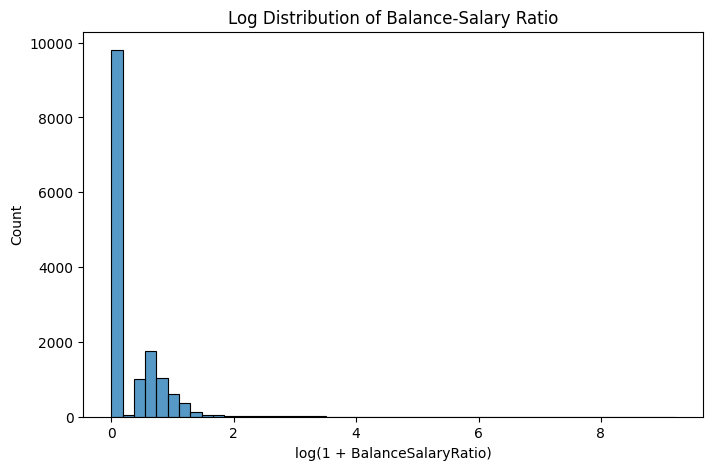

In [69]:
df_train["BalanceSalaryRatio"] = df_train["Balance"] / (df_train["EstimatedSalary"] + 1)
df_test["BalanceSalaryRatio"] = df_test["Balance"] / (df_test["EstimatedSalary"] + 1)


plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_train["BalanceSalaryRatio"]), bins=50)

plt.title("Log Distribution of Balance-Salary Ratio")
plt.xlabel("log(1 + BalanceSalaryRatio)")
plt.show()

Adding +1 prevents division by zero.

Interpretation:

High ratio → customer stores a lot of money in the bank

Low ratio → customer keeps little balance relative to salary

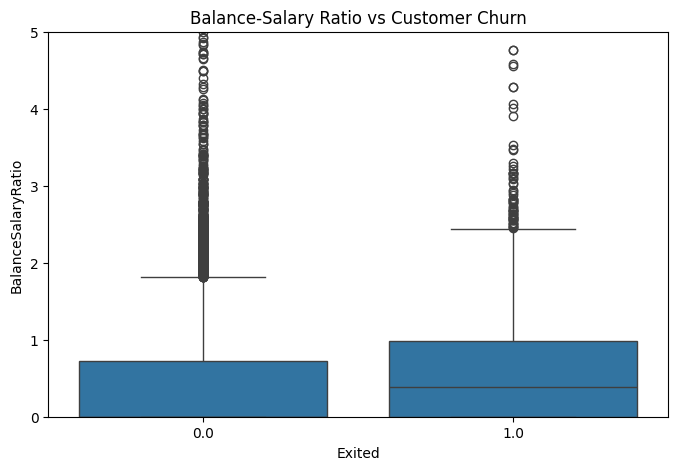

In [70]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Exited", y="BalanceSalaryRatio", data=df_train)

plt.ylim(0, 5)
plt.title("Balance-Salary Ratio vs Customer Churn")
plt.show()

**Balance–Salary Ratio Analysis**

To better understand customer financial behavior, a new feature called BalanceSalaryRatio was created. This feature measures the relationship between a customer's account balance and their estimated salary. It represents how much money a customer keeps in their bank account relative to their income.

The distribution of this feature is highly skewed. Most customers have a low balance-to-salary ratio, meaning that their account balance is small compared to their salary. However, a small number of customers exhibit extremely high ratios. These outliers are likely caused by customers with very small estimated salaries but relatively large account balances, which leads to unusually large ratio values.

The boxplot comparing BalanceSalaryRatio and churn status (Exited) suggests that the ratio may capture differences in financial behavior between customers who remain with the bank and those who leave. Customers with higher ratios may represent individuals who keep a significant portion of their financial resources in the bank, while lower ratios may indicate less engagement with banking services.

Although the feature contains extreme values, tree-based machine learning models such as CatBoost are generally robust to skewed distributions and outliers. Therefore, this feature can still provide useful information for predicting customer churn.

In [71]:
df_train["BalanceSalaryRatio"].skew()

np.float64(86.12067138639816)

The Balance–Salary Ratio shows an extremely right-skewed distribution with a skewness value of 86.12. Most customers have very small ratios, while a few customers have extremely large values due to high balances combined with very low reported salaries. To better visualize this feature, a log transformation was applied. Despite the skewness, tree-based models such as CatBoost can still effectively utilize this feature.

# **Customer Engagement Score**

Customer engagement reflects how actively a customer interacts with the bank's services. Customers who use multiple products, remain active, and maintain longer relationships with the bank are generally less likely to leave.

To capture this behavior, we create a feature called EngagementScore, which combines the number of bank products used and whether the customer is an active member.

In [72]:
df_train["EngagementScore"] = df_train["NumOfProducts"] * df_train["IsActiveMember"]
df_test["EngagementScore"] = df_test["NumOfProducts"] * df_test["IsActiveMember"]

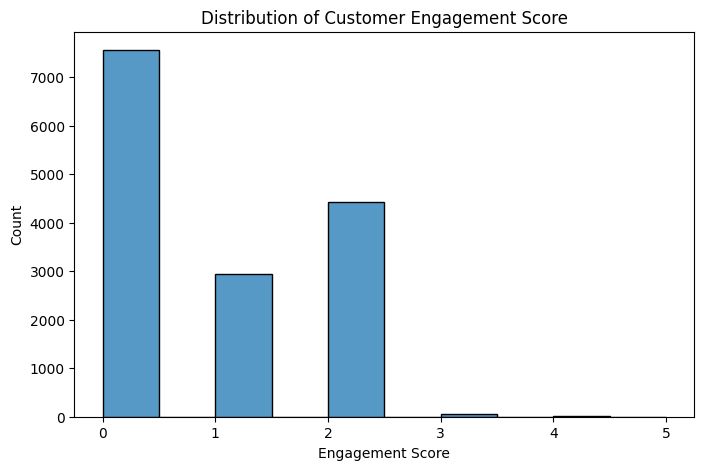

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df_train["EngagementScore"], bins=10)

plt.title("Distribution of Customer Engagement Score")
plt.xlabel("Engagement Score")
plt.show()

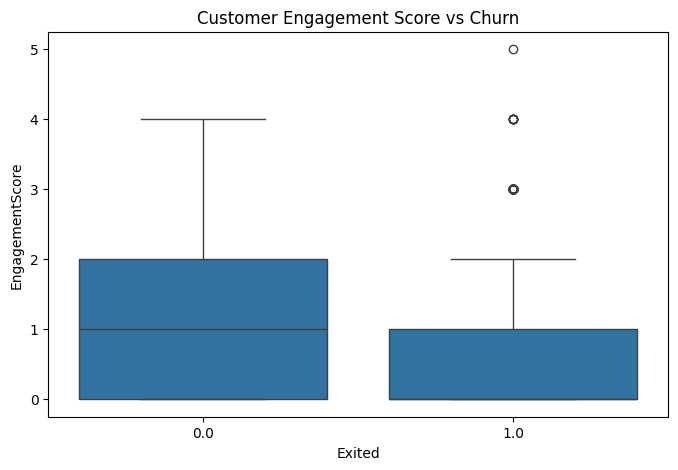

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Exited", y="EngagementScore", data=df_train)

plt.title("Customer Engagement Score vs Churn")
plt.show()

The EngagementScore feature was created to measure how actively a customer interacts with the bank's services. It combines the number of products used by the customer and whether the customer is an active member.

The distribution shows that most customers have low engagement scores, meaning they either use few banking products or are not active members.

The comparison between churned and retained customers suggests that customers with lower engagement scores tend to churn more frequently, while customers with higher engagement levels are more likely to remain with the bank. This indicates that customer engagement may be an important factor in predicting churn.

# **Age Group**

Age is an important demographic factor that can influence customer behavior. Different age groups often exhibit different financial habits and levels of engagement with banking services.

To better capture these behavioral differences, the Age variable is divided into several categorical groups representing different life stages.

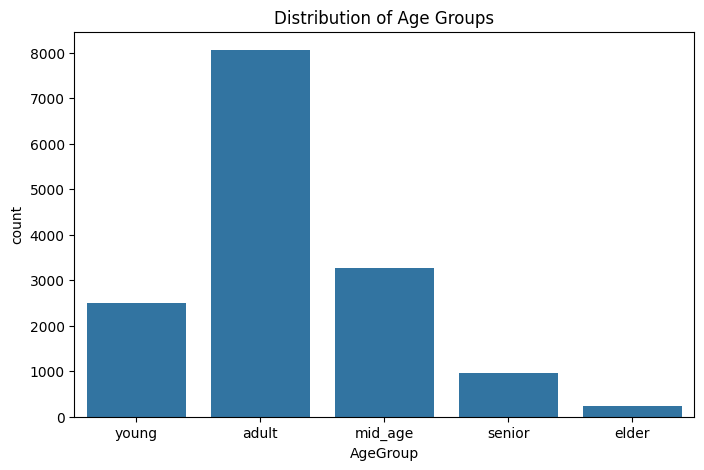

In [75]:
df_train["AgeGroup"] = pd.cut(
    df_train["Age"],
    bins=[18,30,40,50,60,100],
    labels=["young","adult","mid_age","senior","elder"]
)

df_test["AgeGroup"] = pd.cut(
    df_test["Age"],
    bins=[18,30,40,50,60,100],
    labels=["young","adult","mid_age","senior","elder"]
)

plt.figure(figsize=(8,5))
sns.countplot(x="AgeGroup", data=df_train)

plt.title("Distribution of Age Groups")
plt.show()

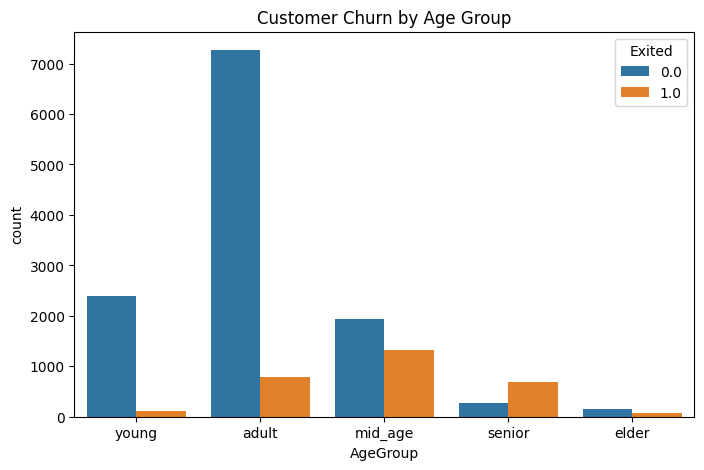

In [76]:
plt.figure(figsize=(8,5))
sns.countplot(x="AgeGroup", hue="Exited", data=df_train)

plt.title("Customer Churn by Age Group")
plt.show()

The AgeGroup feature categorizes customers into different life stages based on their age. The visualization suggests that churn behavior varies across age groups, with older customers generally showing higher churn rates compared to younger customers. This indicates that age-related behavioral patterns may play an important role in predicting customer churn.

# **Data Preprocessing**

Before training the machine learning model, the dataset must be prepared and cleaned. Data preprocessing ensures that the model receives relevant and properly formatted features.

In this step, we remove unnecessary identifiers, define the target variable, and prepare categorical features for the model.

**1. Remove Irrelevant Columns**

Some columns do not provide useful information for prediction because they are only identifiers.

Examples include:

* CustomerId → unique identifier

* Surname → customer name

* id → dataset row index

These columns are removed from the dataset.

In [77]:
df_train = df_train.drop(["CustomerId", "Surname"], axis=1)
df_test = df_test.drop(["CustomerId", "Surname"], axis=1)

**2. Define Target Variable**

The goal of the model is to predict whether a customer will leave the bank.

In [78]:
y = df_train["Exited"]
X = df_train.drop(["Exited", "id"], axis=1)

**3. Identify Categorical Features**

CatBoost requires us to specify which columns are categorical.

In [79]:
cat_cols = ["Geography", "Gender", "AgeGroup"]

for col in cat_cols:
    X[col] = X[col].astype(str)
    df_test[col] = df_test[col].astype(str)

This ensures the model treats them as categorical variables rather than numerical values.

**4. Train–Validation Split**

To evaluate model performance properly, the dataset is divided into training and validation sets.

In [80]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Explanation:

* 80% training data

* 20% validation data

Using stratify=y ensures that the proportion of churned and non-churned customers remains similar in both datasets.

**5. Prepare Test Features**

Remove the id column and store it for submission.

In [81]:
test_ids = df_test["id"]

X_test = df_test.drop(["id"], axis=1)

**Result**

After preprocessing:

* X_train → training features

* X_val → validation features

* y_train → training labels

* y_val → validation labels

* X_test → test dataset

The data is now ready for model training.

# **Moddel Training**

After preprocessing the dataset and preparing the features, the next step is to train a machine learning model capable of predicting customer churn. For this task, we use CatBoost, a gradient boosting algorithm designed for tabular data that can handle categorical features efficiently.

CatBoost is particularly well-suited for this problem because it:

* handles categorical variables natively

* performs well on structured datasets

* is robust to outliers and skewed distributions

**1. Create CatBoost Data Pools**

CatBoost uses a special data structure called a Pool, which stores the dataset along with information about categorical features.

In [82]:
train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_cols
)

val_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_cols
)

**2. Define Model Parameters**

We configure the CatBoost model using several hyperparameters that control learning behavior.

In [83]:
model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

**Parameter explanation**

Parameter	- Meaning

iterations - maximum number of trees

learning_rate	- step size of each update

depth	- tree complexity

loss_function -	optimization objective

eval_metric -	evaluation metric

early_stopping_rounds	- stops training if validation stops improving

**3. Train the Model**

In [84]:
model.fit(
    train_pool,
    eval_set=val_pool
)

0:	test: 0.8948682	best: 0.8948682 (0)	total: 47.2ms	remaining: 3m 55s
200:	test: 0.9336410	best: 0.9336410 (200)	total: 9.89s	remaining: 3m 56s
400:	test: 0.9339933	best: 0.9341351 (346)	total: 21s	remaining: 4m 1s
600:	test: 0.9338081	best: 0.9341589 (439)	total: 30.6s	remaining: 3m 43s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9341588777
bestIteration = 439

Shrink model to first 440 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=200, eval_metric='AUC', iterations=5000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=200)

During training, the model will monitor the validation performance and stop early if improvements stop.

**4. Evaluate Model Performance**

After training, we evaluate the model on the validation set.

In [85]:
val_preds = model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, val_preds)

print("Validation AUC:", auc)

Validation AUC: 0.9341588776882895


**Why AUC?**

The ROC-AUC score measures how well the model distinguishes between churned and non-churned customers.

**5. Feature Importance**

Understanding which features influence the model is important for interpretation.

In [86]:
feature_importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
6,NumOfProducts,31.628803
3,Age,21.823696
11,EngagementScore,8.926883
1,Geography,7.147953
5,Balance,5.033122
10,BalanceSalaryRatio,4.664487
2,Gender,4.366856
0,CreditScore,3.845995
8,IsActiveMember,3.601480
12,AgeGroup,3.373319


**6. Visualize Feature Importance**

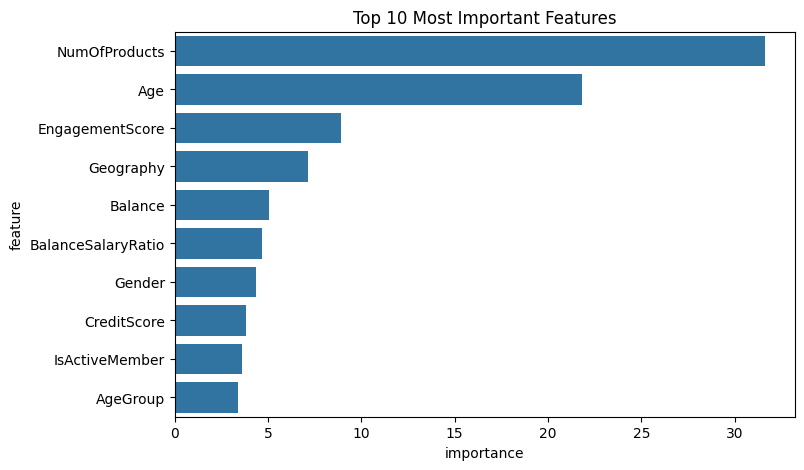

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

**Interpretation**

The CatBoost model was trained using both numerical and categorical features. The validation AUC score indicates that the model can effectively distinguish between customers who churn and those who remain. Feature importance analysis highlights which customer attributes contribute most strongly to the prediction.

**Feature Importance Analysis**

The feature importance plot shows which variables contribute most to the CatBoost model's predictions.

The most influential feature is NumOfProducts, suggesting that the number of banking products a customer uses plays a major role in predicting churn. Customers with fewer products may have weaker engagement with the bank and may therefore be more likely to leave.

The second most important feature is Age, indicating that customer age strongly influences churn behavior. Different age groups may have different financial needs and loyalty patterns.

The engineered feature EngagementScore also appears among the top predictors, confirming that customer interaction with the bank’s services is an important indicator of churn risk.

Other features such as Geography, Balance, and Gender also contribute to the model, although to a lesser extent. Overall, the model relies on a combination of demographic, financial, and behavioral features to predict whether a customer will leave the bank.

# **Generating Predictions for the Test Dataset and Creating the Submission File**

After training and evaluating the CatBoost model on the validation set, the final step is to generate predictions for the unseen test dataset. These predictions are then saved in the required submission format.

Since the target variable represents customer churn, the model outputs the probability that each customer will leave the bank.

**1. Prepare the Test Data**

Make sure the test dataset has the same structure as the training features.

In [88]:
X_test = df_test.drop(["id"], axis=1)

for col in cat_cols:
    X_test[col] = X_test[col].astype(str)

**2. Create the Test Pool**

In [89]:
test_pool = Pool(
    X_test,
    cat_features=cat_cols
)

**3. Generate Predictions**

In [90]:
test_preds = model.predict_proba(test_pool)[:, 1]

**4. Create the Submission File**

In [92]:
submission = pd.DataFrame({
    "id": test_ids,
    "Exited": test_preds
})
submission.head()

,id,Exited
0,15000,0.043412
1,15001,0.146564
2,15002,0.036350
3,15003,0.150712
4,15004,0.010275


**5. Save the Submission**

In [ ]:
submission.to_csv("submission_catboost.csv", index=False)

In [93]:
submission.shape, submission.columns

((10000, 2), Index(['id', 'Exited'], dtype='object'))

# **Model Performance Summary**



**Model Performance**

The CatBoost model was evaluated using the ROC-AUC metric on the validation dataset. The model achieved a validation AUC score of 0.9341588777, indicating that it can effectively distinguish between customers who churn and those who remain.

CatBoost performed well because it can handle categorical variables and complex interactions between customer features.

# **Conclusion**



In this project, a machine learning pipeline was developed to predict customer churn in a banking dataset. The workflow included exploratory data analysis, feature engineering, preprocessing, model training, and model interpretation.

Several engineered features, such as BalanceSalaryRatio, EngagementScore, and AgeGroup, helped capture customer financial behavior and engagement patterns. The CatBoost model was then trained using these features and evaluated using ROC-AUC.

The feature importance analysis revealed that NumOfProducts, Age, and customer engagement were among the most influential predictors of churn. The final model was used to generate churn probabilities for unseen customers and produce a submission file.

Such predictive models can help financial institutions identify high-risk customers and implement targeted retention strategies.